<a href="https://colab.research.google.com/github/dfields0388-bot/data-science-portfolio/blob/main/MTG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')
nbdir = "/content/gdrive/My Drive/DSCI_591/"

Mounted at /content/gdrive/


Define working directory

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
nbdir = "/content/gdrive/My Drive/DSCI_591/"
os.makedirs(nbdir, exist_ok=True)

nbdir

'/content/gdrive/My Drive/DSCI_591/'

Download MTGJSON directly into that folder

In [ ]:
# Download AllPrintings.json directly into Google Drive
!wget -O "/content/gdrive/My Drive/DSCI_591/AllPrintings.json" https://mtgjson.com/api/v5/AllPrintings.json

--2026-02-22 18:38:05--  https://mtgjson.com/api/v5/AllPrintings.json
Resolving mtgjson.com (mtgjson.com)... 172.67.154.80, 104.21.64.186, 2606:4700:3034::ac43:9a50, ...
Connecting to mtgjson.com (mtgjson.com)|172.67.154.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 536029691 (511M) [application/json]
Saving to: ‘/content/gdrive/My Drive/DSCI_591/AllPrintings.json’

/content/gdrive/My  100%[===================>] 511.20M  2.89MB/s    in 2m 57s  

2026-02-22 18:41:03 (2.88 MB/s) - ‘/content/gdrive/My Drive/DSCI_591/AllPrintings.json’ saved [536029691/536029691]



Load the data from Google Drive

In [ ]:
file_path = "/content/gdrive/My Drive/DSCI_591/AllPrintings.json"

with open(file_path, "r") as f:
    data = json.load(f)

cards = []
for set_data in data["data"].values():
    cards.extend(set_data["cards"])

df = pd.DataFrame(cards)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (109008, 86)


,artist,artistIds,availability,boosterTypes,borderColor,colorIdentity,colors,convertedManaCost,edhrecRank,edhrecSaltiness,...,isOversized,duelDeck,isTextless,isTimeshifted,defense,faceFlavorName,facePrintedName,signature,subsets,attractionLights
0,Pete Venters,[d54c4a1a-c0c5-4834-84db-125d341f3ad8],"[mtgo, paper]",[default],black,[W],[W],7.0,24046.0,0.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Pete Venters,[d54c4a1a-c0c5-4834-84db-125d341f3ad8],"[mtgo, paper]",[default],black,[W],[W],7.0,24046.0,0.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Volkan Baǵa,[93bec3c0-0260-4d31-8064-5d01efb4153f],"[mtgo, paper]",[default],black,[W],[W],5.0,18816.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Volkan Baǵa,[93bec3c0-0260-4d31-8064-5d01efb4153f],"[mtgo, paper]",[default],black,[W],[W],5.0,18816.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Mark Zug,[48e2b98c-5467-4671-bd42-4c3746115117],"[mtgo, paper]",[default],black,[W],[W],3.0,25189.0,0.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for col in df.columns:
    print(col)


artist
artistIds
availability
boosterTypes
borderColor
colorIdentity
colors
convertedManaCost
edhrecRank
edhrecSaltiness
finishes
foreignData
frameVersion
identifiers
isReprint
keywords
language
layout
legalities
manaCost
manaValue
name
number
originalText
power
printings
purchaseUrls
rarity
setCode
sourceProducts
subtypes
supertypes
text
toughness
type
types
uuid
variations
flavorText
rulings
leadershipSkills
relatedCards
isAlternative
promoTypes
hasAlternativeDeckLimit
producedMana
isGameChanger
isReserved
hasContentWarning
frameEffects
securityStamp
loyalty
isFullArt
isPromo
asciiName
flavorName
printedName
printedText
printedType
watermark
isOnlineOnly
colorIndicator
faceConvertedManaCost
faceManaValue
faceName
otherFaceIds
side
isStorySpotlight
rebalancedPrintings
isRebalanced
originalPrintings
originalReleaseDate
cardParts
hand
isFunny
life
isOversized
duelDeck
isTextless
isTimeshifted
defense
faceFlavorName
facePrintedName
signature
subsets
attractionLights


Keep only needed columns

In [ ]:
# # Check what supertypes look like
# df["supertypes"].head(10)

# df["supertypes"].isna().sum(), len(df)

# df["isLegendary"] = df["supertypes"].apply(
#     lambda x: "Legendary" in x
# )

# df["isLegendary"].value_counts()

# df.loc[df["isLegendary"], ["name", "supertypes"]].head(10)

# # How many are empty vs non-empty?
# df["supertypes"].apply(lambda x: len(x) if isinstance(x, list) else None).value_counts().head(10)

# # Show the most common supertypes entries (as tuples so they’re countable)
# df["supertypes"].apply(lambda x: tuple(x) if isinstance(x, list) else ("MISSING",)).value_counts().head(20)

# # Count cards that are Legendary (if supertypes is properly present)
# legendary_count = df["supertypes"].apply(lambda x: "Legendary" in x if isinstance(x, list) else False).sum()
# legendary_count

In [ ]:
# Create derived isLegendary feature from supertypes
df["isLegendary"] = df["supertypes"].apply(
    lambda x: "Legendary" in x
)

columns_to_keep = [
    "name", "manaValue", "power", "toughness",
    "colors", "colorIdentity", "types", "type",
    "rarity", "text", "supertypes", "isLegendary"
]

df_reduced = df[columns_to_keep]

Save CSV for faster reuse

In [ ]:


csv_path = "/content/gdrive/My Drive/DSCI_591/mtg_cards_reduced.csv"
df_reduced.to_csv(csv_path, index=False)

csv_path

'/content/gdrive/My Drive/DSCI_591/mtg_cards_reduced.csv'

In [ ]:
df = pd.read_csv(csv_path)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (109008, 12)


,name,manaValue,power,toughness,colors,colorIdentity,types,type,rarity,text,supertypes,isLegendary
0,Ancestor's Chosen,7.0,4,4,['W'],['W'],['Creature'],Creature — Human Cleric,uncommon,First strike (This creature deals combat damag...,[],False
1,Ancestor's Chosen,7.0,4,4,['W'],['W'],['Creature'],Creature — Human Cleric,uncommon,First strike (This creature deals combat damag...,[],False
2,Angel of Mercy,5.0,3,3,['W'],['W'],['Creature'],Creature — Angel,uncommon,"Flying\nWhen this creature enters, you gain 3 ...",[],False
3,Angel of Mercy,5.0,3,3,['W'],['W'],['Creature'],Creature — Angel,uncommon,"Flying\nWhen this creature enters, you gain 3 ...",[],False
4,Angelic Blessing,3.0,NaN,NaN,['W'],['W'],['Sorcery'],Sorcery,common,Target creature gets +3/+3 and gains flying un...,[],False


In [ ]:
# Count total duplicate rows
df.duplicated().sum()

np.int64(70786)

Because the dataset contains multiple printings of the same card across sets, analysis at the print-level may bias mana value distributions toward frequently reprinted cards. To ensure analysis reflects intrinsic card characteristics rather than reprint frequency, duplicate card names were removed prior to calculating descriptive statistics.


HISTOGRAMS

manaValue


*   It was discovered there were outlier values, values less than 0 and values of 100000000.
*   These are unrealistic values and were removed




CONTAINS DUPLICATES

In [ ]:
# Describes the data distribution
df["manaValue"].dtype
df["manaValue"].describe()
df["manaValue"].max()
df.loc[df["manaValue"].nlargest(10).index, ["name", "manaValue"]]
df["manaValue"].value_counts(dropna=False).head(20)

,count
manaValue,
3.0,23153
2.0,20965
4.0,17969
0.0,13826
5.0,11259
1.0,10532
6.0,6304
7.0,2928
8.0,1192


In [ ]:
# Ensures manaValue is a numeric variable
df["manaValue"] = pd.to_numeric(df["manaValue"], errors="coerce")

# Ensures Values are within 0 - 20
df = df[(df["manaValue"] >= 0) & (df["manaValue"] <= 20)]
df["manaValue"].describe()

,manaValue
count,109006.000000
mean,2.997775
std,1.985198
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,16.000000


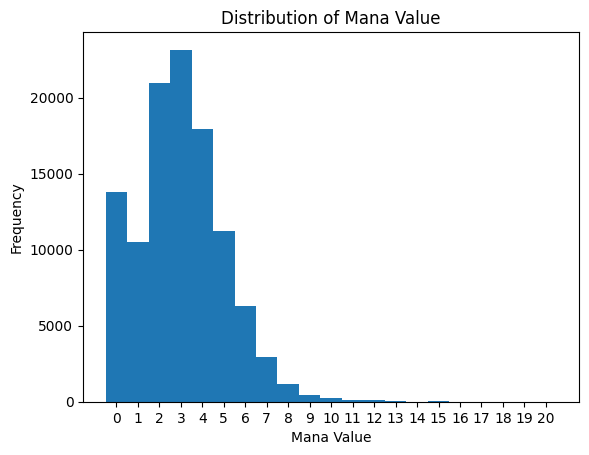

In [ ]:
# manaValue Histogram
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["manaValue"], bins=range(0, 22), align="left")
plt.xticks(range(0, 21))
plt.xlabel("Mana Value")
plt.ylabel("Frequency")
plt.title("Distribution of Mana Value")
plt.show()

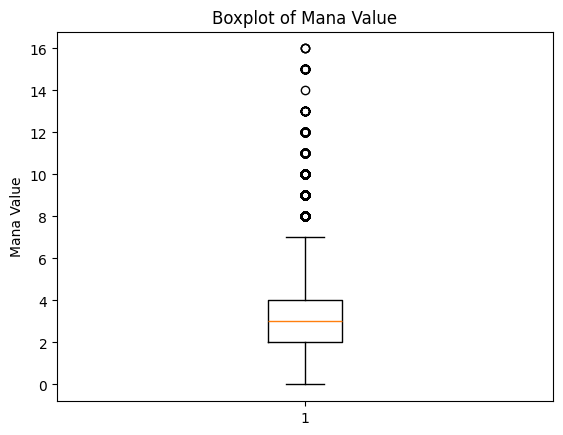

In [ ]:
# Box Plot
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df["manaValue"].dropna())
plt.ylabel("Mana Value")
plt.title("Boxplot of Mana Value")
plt.show()

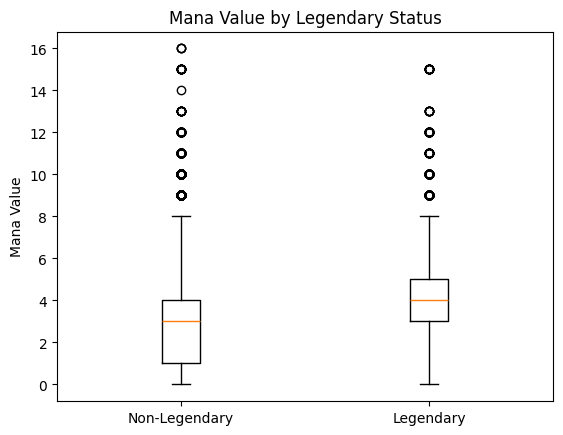

In [ ]:
legendary = df[df["isLegendary"] == True]["manaValue"]
non_legendary = df[df["isLegendary"] == False]["manaValue"]

plt.figure()
plt.boxplot([non_legendary, legendary])
plt.xticks([1, 2], ["Non-Legendary", "Legendary"])
plt.ylabel("Mana Value")
plt.title("Mana Value by Legendary Status")
plt.show()

In [ ]:
# MEAN, MEDIAN AND MODE
mv = df["manaValue"].dropna()

mean_mv = mv.mean()
median_mv = mv.median()
mode_mv = mv.mode()[0]

mean_mv, median_mv, mode_mv

(np.float64(2.9977753518154966), 3.0, np.float64(3.0))

In [ ]:
# SKEWNESS
skew_mv = mv.skew()
skew_mv

np.float64(0.5785115694810881)

RESULTS:
The mana value distribution has a mean, median, and mode of 3, indicating strong central concentration at three mana. The skewness value of 0.58 suggests a mildly right-skewed distribution, reflecting the presence of fewer high-cost cards that extend the upper tail of the distribution.

Your data shows:
	•	Most cards cost 2–4 mana
	•	Very few cost above 8
	•	The game design emphasizes mid-range cost efficiency


DE-DUPLICATED

In [ ]:
# Deduplicated
df_unique = df.drop_duplicates(subset=["name"])
df_unique["manaValue"].mean()

np.float64(3.2302142219577505)

In [ ]:
# Ensures manaValue is a numeric variable
df_unique["manaValue"] = pd.to_numeric(df_unique["manaValue"], errors="coerce")

# Ensures Values are within 0 - 20
df_unique = df_unique[(df["manaValue"] >= 0) & (df_unique["manaValue"] <= 20)]
df_unique["manaValue"].describe()

/tmp/ipython-input-3425472842.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique["manaValue"] = pd.to_numeric(df_unique["manaValue"], errors="coerce")
/tmp/ipython-input-3425472842.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_unique = df_unique[(df["manaValue"] >= 0) & (df_unique["manaValue"] <= 20)]


,manaValue
count,33610.000000
mean,3.230214
std,1.793275
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,16.000000


In [ ]:
# MEAN, MEDIAN AND MODE
mv_mana = df_unique["manaValue"].dropna()

mean_mv_mana = mv_mana.mean()
median_mv_mana = mv_mana.median()
mode_mv_mana = mv_mana.mode()[0]

mean_mv_mana, median_mv_mana, mode_mv_mana

(np.float64(3.2302142219577505), 3.0, np.float64(3.0))

In [ ]:
# SKEWNESS
skew_mv_mana = mv_mana.skew()
skew_mv_mana

np.float64(0.5804474556675102)

In [ ]:
print(f"Mean: {mean_mv_mana:.2f}")
print(f"Median: {median_mv_mana:.2f}")
print(f"Mode: {mode_mv_mana}")
print(f"Skewness: {skew_mv_mana:.2f}")

Mean: 3.23
Median: 3.00
Mode: 3.0
Skewness: 0.58


In the de-duplicated dataset, mana value is concentrated between 1 and 5, with a clear peak around 2–4. The distribution is right-skewed with a long tail, meaning high-cost cards exist but are much less common than low-cost cards. A small number of zero-cost entries and extreme outliers (e.g., very large mana values) appear, which likely reflect special card types or dataset encoding/placeholder values rather than typical gameplay costs.

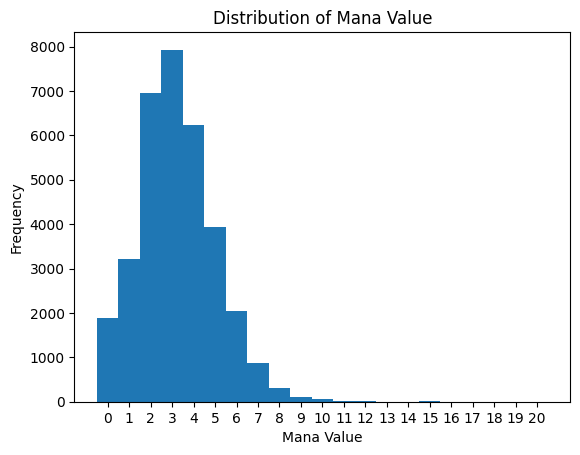

In [ ]:
# manaValue Histogram
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_unique["manaValue"], bins=range(0, 22), align="left")
plt.xticks(range(0, 21))
plt.xlabel("Mana Value")
plt.ylabel("Frequency")
plt.title("Distribution of Mana Value")
plt.show()

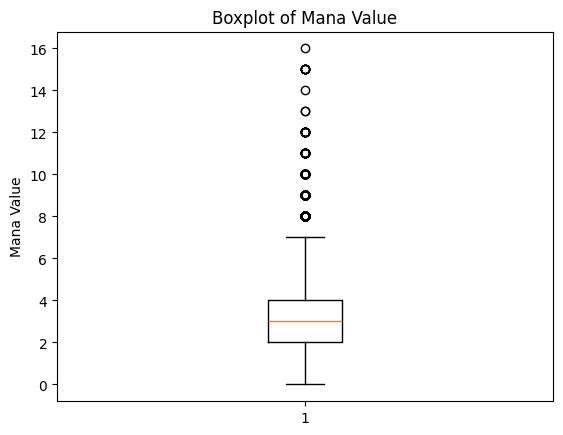

In [ ]:
# Box Plot
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_unique["manaValue"].dropna())
plt.ylabel("Mana Value")
plt.title("Boxplot of Mana Value")
plt.show()

RARITY

In [ ]:
rarity_counts = df_unique["rarity"].value_counts()
rarity_counts

,count
rarity,
common,10851
rare,10753
uncommon,9829
mythic,2167
special,10


In [ ]:
df["rarity"].unique()

array(['uncommon', 'common', 'rare', 'mythic', 'special', 'bonus'],
      dtype=object)

After removing duplicate card names, the rarity distribution becomes more balanced, with Common (32.3%), Rare (32.0%), and Uncommon (29.2%) appearing in similar proportions, and Mythic representing 6.4%. Compared to the non-deduplicated dataset, Rare decreases by approximately 5.7 percentage points and Mythic decreases by 3 percentage points. This indicates that higher-rarity cards are more frequently reprinted or appear in multiple products, leading to inflation in print-level analyses. Deduplication by name provides a clearer view of intrinsic card design distribution rather than printing frequency.

In [ ]:
rarity_freq = df_unique["rarity"].value_counts().to_frame()
rarity_freq.columns = ["Count"]
rarity_freq["Percentage"] = (rarity_freq["Count"] / len(df)) * 100
rarity_freq

,Count,Percentage
rarity,,
common,10851,9.954498
rare,10753,9.864595
uncommon,9829,9.016935
mythic,2167,1.987964
special,10,0.009174


In [ ]:
df_unique["rarity"].value_counts()

,count
rarity,
common,10851
rare,10753
uncommon,9829
mythic,2167
special,10


In the de-duplicated dataset (unique cards only), Common and Uncommon make up the majority of cards, while Rare and Mythic represent a smaller share. Compared with the non-deduplicated data, Rare decreases noticeably, suggesting that duplicate entries (e.g., multiple printings/variants) were inflating Rare counts in the full dataset. Special/Bonus rarities remain a very small portion and likely reflect promotional or dataset-specific categories rather than standard set distributions.

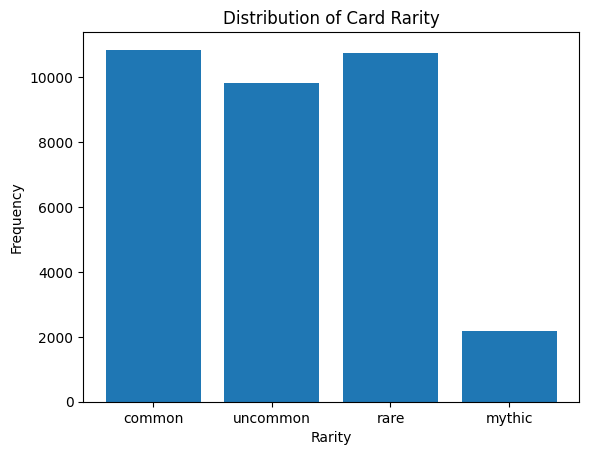

In [ ]:
order = ["common", "uncommon", "rare", "mythic"]

rarity_counts = df_unique["rarity"].value_counts().reindex(order)

plt.figure()
plt.bar(rarity_counts.index, rarity_counts.values)
plt.xlabel("Rarity")
plt.ylabel("Frequency")
plt.title("Distribution of Card Rarity")
plt.show()

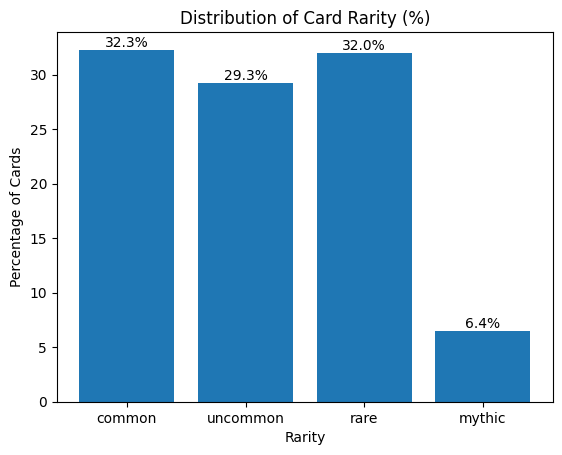

,count
rarity,
common,32.294643
uncommon,29.252976
rare,32.002976
mythic,6.449405


In [ ]:
order = ["common", "uncommon", "rare", "mythic"]

# counts in fixed order
rarity_counts = df_unique["rarity"].value_counts().reindex(order)

# convert to percentages
rarity_pct = rarity_counts / rarity_counts.sum() * 100

# plot
plt.figure()
plt.bar(rarity_pct.index, rarity_pct.values)

plt.xlabel("Rarity")
plt.ylabel("Percentage of Cards")
plt.title("Distribution of Card Rarity (%)")

# add percent labels
for i, v in enumerate(rarity_pct.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.show()

rarity_pct

In [ ]:
# ENSURING DE-DUPLICATING BY NAME TRULY RESULTS IN ONE CARD PER NAME
df_unique["rarity"].value_counts()
df.groupby("name")["rarity"].nunique()

,rarity
name,
"""Ach! Hans, Run!""",1
"""Brims"" Barone, Midway Mobster",1
"""Lifetime"" Pass Holder",1
"""Name Sticker"" Goblin",1
"""Rumors of My Death . . .""",1
...,...
"Éomer, King of Rohan",1
"Éomer, Marshal of Rohan",1
"Éowyn, Fearless Knight",1


COLOR

The majority of unique cards are mono-colored (approximately 24,353 cards), indicating that MTG design space is primarily structured around single-color archetypes. Two-color cards represent the largest multi-color category (~4,703), reflecting the importance of dual-color strategies in set design (e.g., guild-based mechanics). Three-color cards are significantly less common (~940), while four-color and five-color cards are rare. Colorless cards (~3,434) represent a meaningful subset, including artifacts and special design categories. Overall, the distribution reflects MTG’s foundational emphasis on mono-color play with structured expansion into multi-color archetypes.

In [ ]:
# import pandas as pd

# Make sure you're using deduplicated dataset
# df_unique = df_unique.copy()

# Explode colorIdentity
df_colors = df_unique.explode("colorIdentity")

# Count occurrences
color_counts = df_colors["colorIdentity"].value_counts()

color_counts

,count
colorIdentity,
['W'],4928
['B'],4907
['R'],4892
['U'],4843
['G'],4783
[],3434
"['B', 'R']",515
"['B', 'U']",507
"['U', 'W']",506


In [ ]:
df_unique["num_colors"] = df_unique["colorIdentity"].apply(len)

mono_multi_counts = df_unique["num_colors"].value_counts().sort_index()

mono_multi_counts

,count
num_colors,
2,3434
5,24353
10,4703
15,940
20,23
25,157


MONO VS. MULTI COLOR

* 0   (Colorless)
* 1   (Mono-color)
* 2   (Two-color)
* 3   (Three-color)
* 4   (Four-color)
* 5   (Five-color)

The vast majority of unique cards are mono-colored (24,353 cards), confirming that MTG design space is primarily centered around single-color archetypes. Two-color cards represent the most common multi-color category (4,703 cards), reflecting structured dual-color mechanics common across many sets. Three-color cards decline sharply (940), while four-color designs are extremely rare (23). Five-color cards (157) exist but represent a small and specialized portion of the design space. Colorless cards (3,434) form a distinct subset, primarily consisting of artifact-based or mechanically neutral designs.

In [ ]:
import ast

# The 'colorIdentity' column already contains list objects, so ast.literal_eval is not needed.
# df_unique["colorIdentity"] = df_unique["colorIdentity"].apply(ast.literal_eval)

df_unique["num_colors"] = df_unique["colorIdentity"].apply(len)

df_unique["num_colors"].value_counts().sort_index()

,count
num_colors,
2,3434
5,24353
10,4703
15,940
20,23
25,157


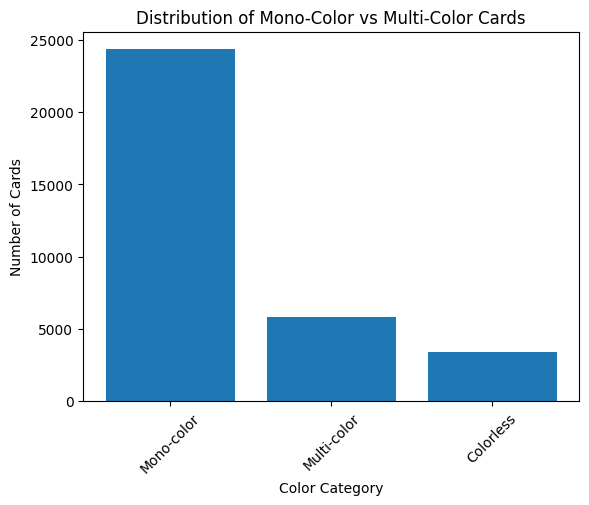

,count
color_category,
Mono-color,24353
Multi-color,5823
Colorless,3434


In [ ]:
# Convert colorIdentity from string to list (only if needed)
df_unique["colorIdentity"] = df_unique["colorIdentity"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Compute number of colors
df_unique["num_colors"] = df_unique["colorIdentity"].apply(len)

# Create simplified category
df_unique["color_category"] = df_unique["num_colors"].apply(
    lambda x: "Colorless" if x == 0
    else "Mono-color" if x == 1
    else "Multi-color"
)

# Count categories
color_distribution = df_unique["color_category"].value_counts()

# Create bar chart (single plot, no custom colors)
plt.figure()
plt.bar(color_distribution.index, color_distribution.values)
plt.xlabel("Color Category")
plt.ylabel("Number of Cards")
plt.title("Distribution of Mono-Color vs Multi-Color Cards")
plt.xticks(rotation=45)
plt.show()

color_distribution

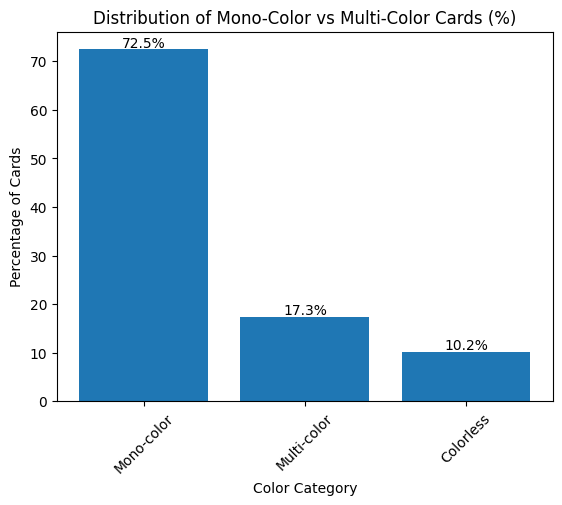

,proportion
color_category,
Mono-color,72.457602
Multi-color,17.325201
Colorless,10.217197


In [ ]:
# Convert counts → percentages
color_distribution = df_unique["color_category"].value_counts(normalize=True) * 100

# Plot
plt.figure()
plt.bar(color_distribution.index, color_distribution.values)

plt.xlabel("Color Category")
plt.ylabel("Percentage of Cards")
plt.title("Distribution of Mono-Color vs Multi-Color Cards (%)")
plt.xticks(rotation=45)

# optional: show % labels above bars
for i, v in enumerate(color_distribution.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.show()

color_distribution

CARD TYPE FREQUENCY

In [ ]:
# types column example: ["Creature"], ["Artifact","Creature"], ["Instant"], etc.

type_counts = (
    df_unique["types"]
    .dropna()
    .explode()
    .value_counts()
    .sort_values(ascending=False)
)

type_counts.head(15)

,count
types,
['Creature'],16844
['Instant'],3712
['Sorcery'],3490
['Enchantment'],3455
['Artifact'],2463
"['Artifact', 'Creature']",1253
['Land'],1120
['Planeswalker'],324
"['Enchantment', 'Creature']",259


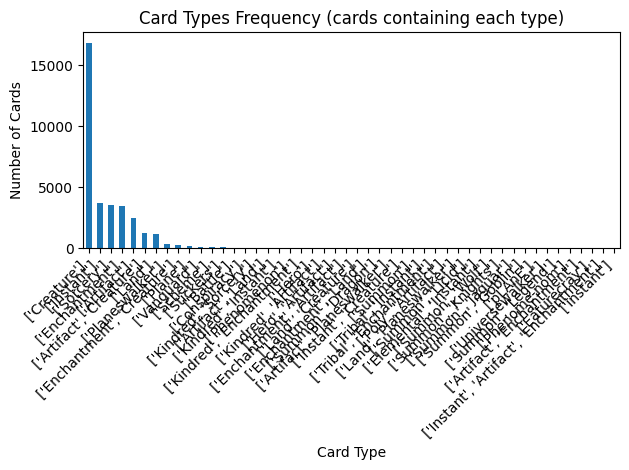

In [ ]:
plt.figure()
type_counts.plot(kind="bar")
plt.xlabel("Card Type")
plt.ylabel("Number of Cards")
plt.title("Card Types Frequency (cards containing each type)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

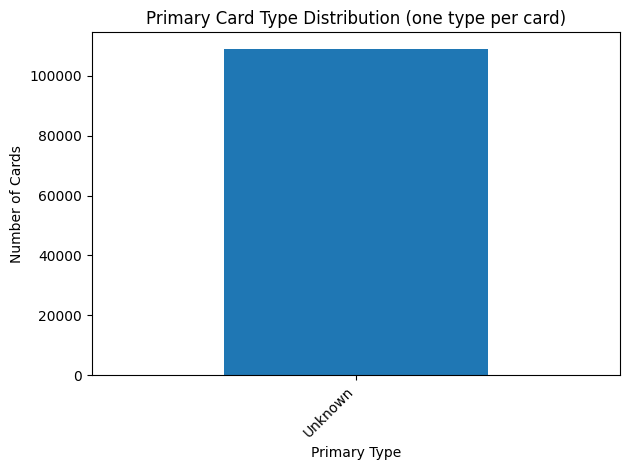

In [ ]:
df["primary_type"] = df["types"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "Unknown")

primary_counts = df["primary_type"].value_counts().sort_values(ascending=False)

plt.figure()
primary_counts.plot(kind="bar")
plt.xlabel("Primary Type")
plt.ylabel("Number of Cards")
plt.title("Primary Card Type Distribution (one type per card)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import ast

major_types = [
    "Creature",
    "Instant",
    "Sorcery",
    "Artifact",
    "Enchantment",
    "Land",
    "Planeswalker",
    "Battle",
    "Tribal"
]

# Ensure 'types' column in df_unique contains actual lists, not string representations
df_unique["types"] = df_unique["types"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

type_counts = (
    df_unique["types"] # Use df_unique for consistency with previous cells
    .dropna()
    .explode()
    .value_counts()
)

major_type_counts = type_counts[type_counts.index.isin(major_types)]

major_type_counts.sort_values(ascending=False)

,count
types,
Creature,18361
Artifact,3764
Enchantment,3745
Instant,3741
Sorcery,3515
Land,1151
Planeswalker,327
Battle,38
Tribal,2


The dataset reveals a heavily creature-dominated design structure, with creatures comprising the overwhelming majority of unique card types. Spell-based cards (Instants and Sorceries) and permanent utility cards (Artifacts and Enchantments) form a balanced secondary tier. Planeswalkers and newer mechanics such as Battles represent a very small, specialized subset of designs. Overall, the distribution confirms that MTG gameplay is structurally centered around creature-based interactions.

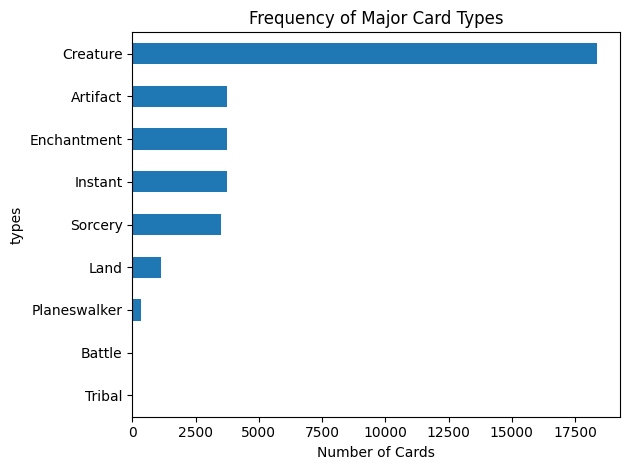

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
major_type_counts.sort_values().plot(kind="barh")
plt.xlabel("Number of Cards")
plt.title("Frequency of Major Card Types")
plt.tight_layout()
plt.show()

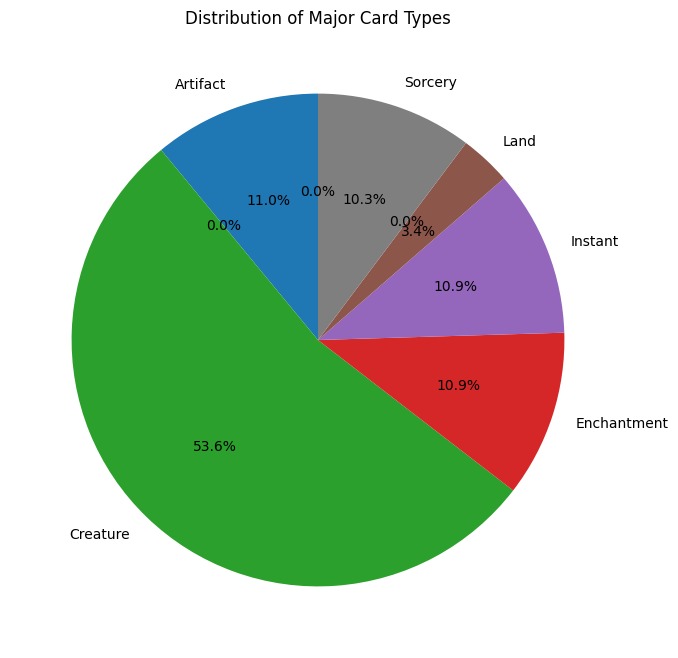

In [ ]:
threshold = 0.01 * major_type_counts.sum()
major_type_counts_clean = major_type_counts.copy()
major_type_counts_clean[major_type_counts < threshold] = 0
major_type_counts_clean = major_type_counts_clean.groupby(major_type_counts_clean.index).sum()

plt.figure(figsize=(8,8))
major_type_counts_clean.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.ylabel("")
plt.title("Distribution of Major Card Types")
plt.show()

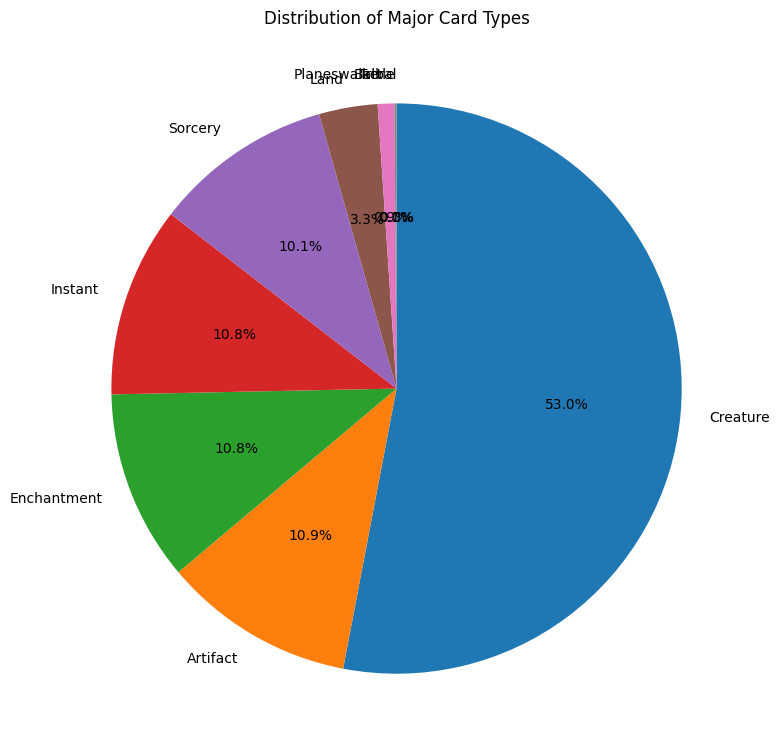

In [ ]:
plt.figure(figsize=(8,8))

major_type_counts.plot(
    kind="pie",
    autopct="%1.1f%%",      # shows percentages
    startangle=90,          # rotates so largest slice starts at top
    counterclock=False
)

plt.title("Distribution of Major Card Types")
plt.ylabel("")              # removes default y-label
plt.tight_layout()
plt.show()

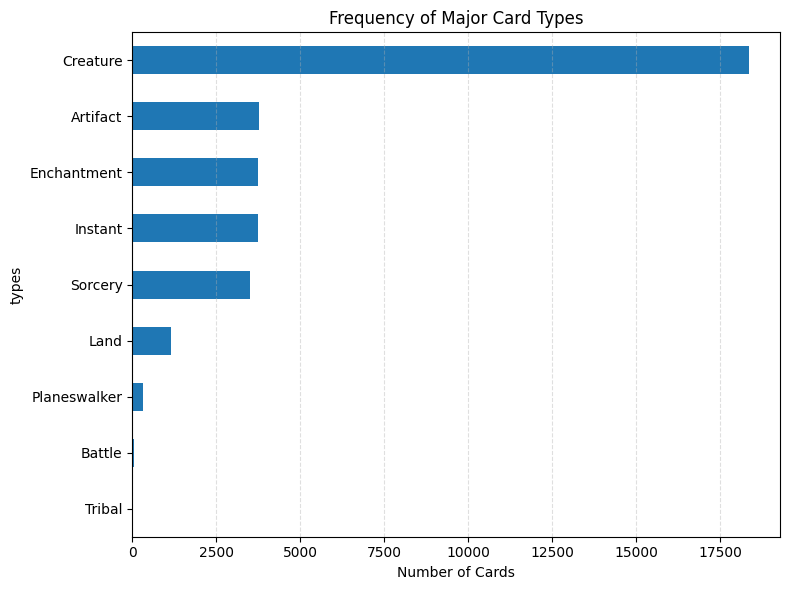

In [ ]:
plt.figure(figsize=(8,6))

major_type_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of Cards")
plt.title("Frequency of Major Card Types")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

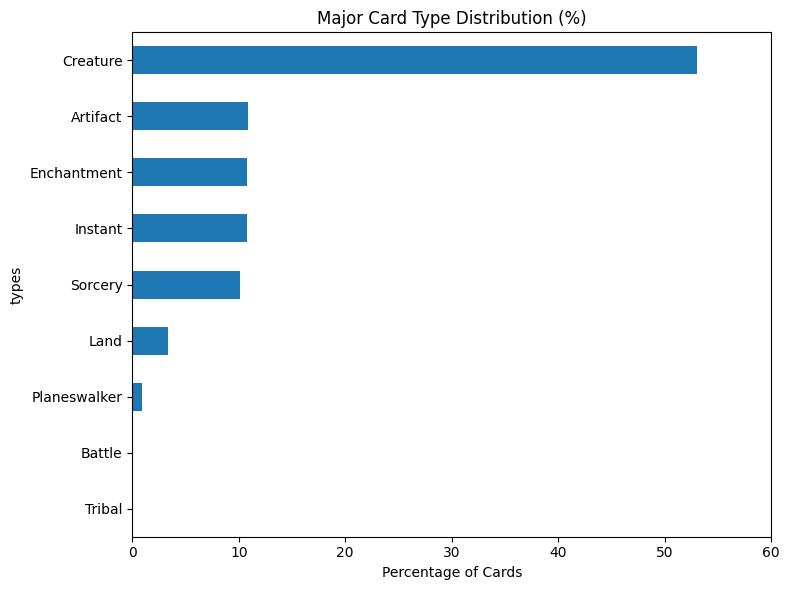

In [ ]:
percent = major_type_counts / major_type_counts.sum() * 100

plt.figure(figsize=(8,6))
percent.sort_values().plot(kind="barh")

plt.xlabel("Percentage of Cards")
plt.title("Major Card Type Distribution (%)")
plt.xlim(0, 60)
plt.tight_layout()
plt.show()

Legendary Cards

In [ ]:
df_unique["isLegendary"] = df_unique["supertypes"].apply(
    lambda x: "Legendary" if isinstance(x, list) and "Legendary" in x else "Non-Legendary"
)

In [ ]:
legendary_pct = df_unique["isLegendary"].value_counts(normalize=True) * 100
legendary_pct = legendary_pct.reindex(["Legendary", "Non-Legendary"])

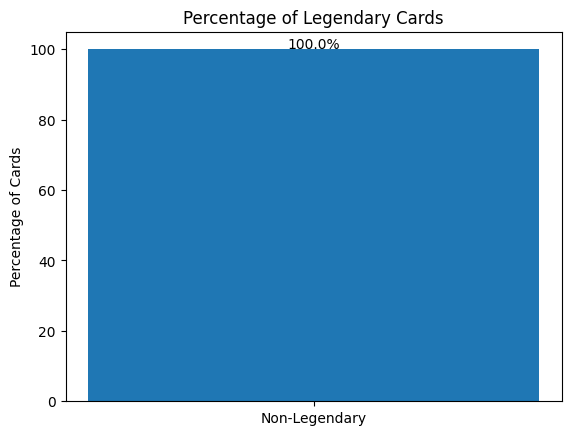

,proportion
isLegendary,
Legendary,NaN
Non-Legendary,100.0


In [ ]:
plt.figure()
plt.bar(legendary_pct.index, legendary_pct.values)

plt.ylabel("Percentage of Cards")
plt.title("Percentage of Legendary Cards")

# add labels
for i, v in enumerate(legendary_pct.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.show()

legendary_pct